In [29]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
from esem import rf_model
from eofs.xarray import Eof
import itertools
import joblib  
from sklearn.metrics import mean_squared_error
from utils import *
from utils_emi2yield_agg import *


In [30]:
train_files= ['ssp126', 'ssp585']

In [16]:
Xtrain = create_predictor_data(train_files)  # Emission input variables
Ytrain = get_Ytrain(train_files)  # Crop yields

Xtest = get_test_data('ssp370')
Ytest = get_Ytest('ssp370')

In [17]:
print(Xtrain.shape)

(172, 4)


In [22]:
# eof_solver_path = "saved_models/eof_solvers.pkl"
# joblib.dump(eof_solvers, eof_solver_path)

['saved_models/eof_solvers.pkl']

### EDA For Crops


Processing region: United States


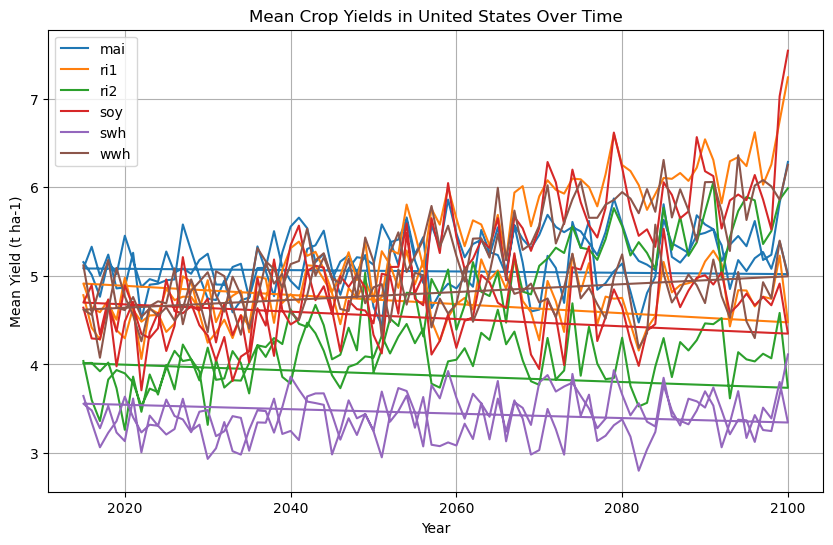


Processing region: Europe


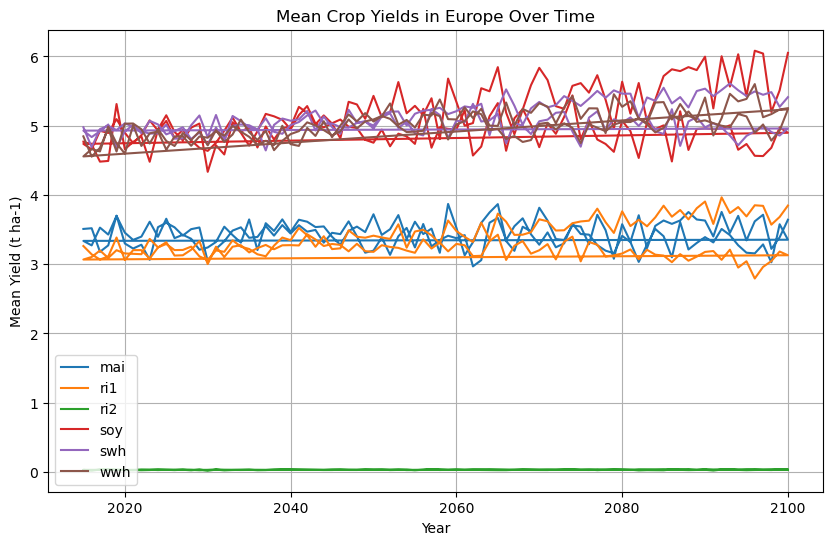


Processing region: Asia


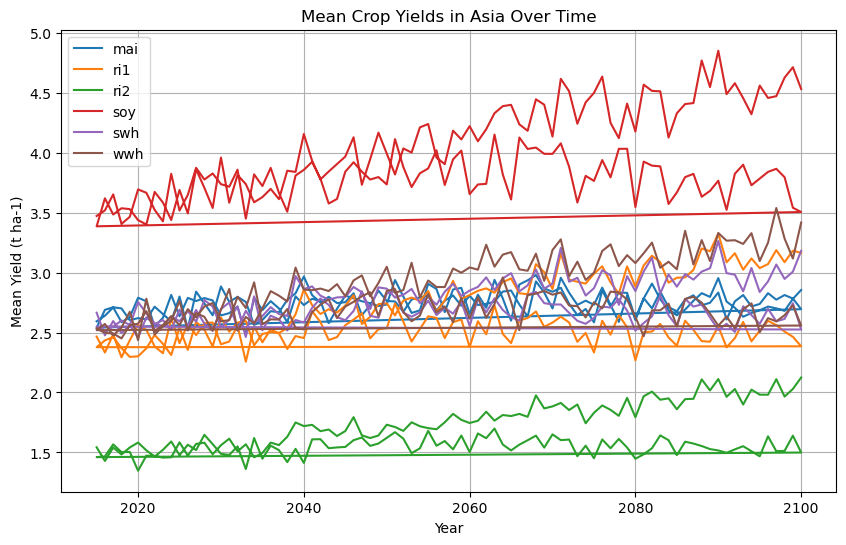


Processing region: Africa


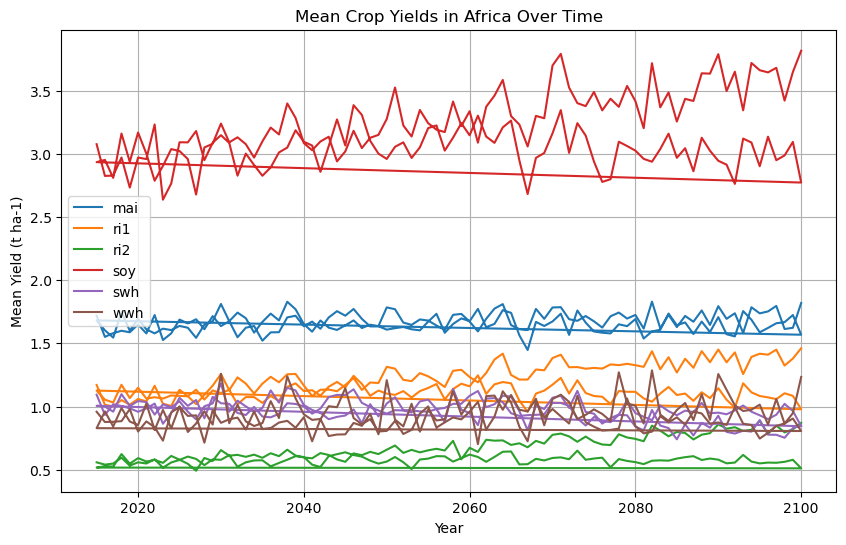

In [32]:
regions = {
    "United States": {"lat": slice(24, 49), "lon": slice(-125, -66)},
    "Europe": {"lat": slice(35, 71), "lon": slice(-25, 40)},  # Western Europe to Eastern Europe
    "Asia": {"lat": slice(5, 55), "lon": slice(60, 150)},  # Middle East to East Asia
    "Africa": {"lat": slice(-35, 37), "lon": slice(-20, 55)},  # Entire African continent
}

# Loop over region
for region, coords in regions.items():
    print(f"\nProcessing region: {region}")

    # Select the region 
    lat_mask = (Ytrain.lat >= coords["lat"].start) & (Ytrain.lat <= coords["lat"].stop)
    lon_mask = (Ytrain.lon >= coords["lon"].start) & (Ytrain.lon <= coords["lon"].stop)
    Ytrain_region = Ytrain.where(lat_mask & lon_mask, drop=True)

    # Check ifregion contains data
    if Ytrain_region.to_array().isnull().all():
        print(f" Warning: No valid data available for {region}. Skipping plot.")
        continue  # Skip to the next region

    # Compute mean crop yields over lat/lon
    region_crop_means = Ytrain_region.mean(dim=["lat", "lon"], skipna=True)

    # Plot mean crop yields over time
    plt.figure(figsize=(10, 6))
    for crop in region_crop_means.data_vars:
        if not region_crop_means[crop].isnull().all(): 
            plt.plot(region_crop_means.time, region_crop_means[crop], label=crop)

    plt.xlabel("Year")
    plt.ylabel("Mean Yield (t ha-1)")
    plt.title(f"Mean Crop Yields in {region} Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

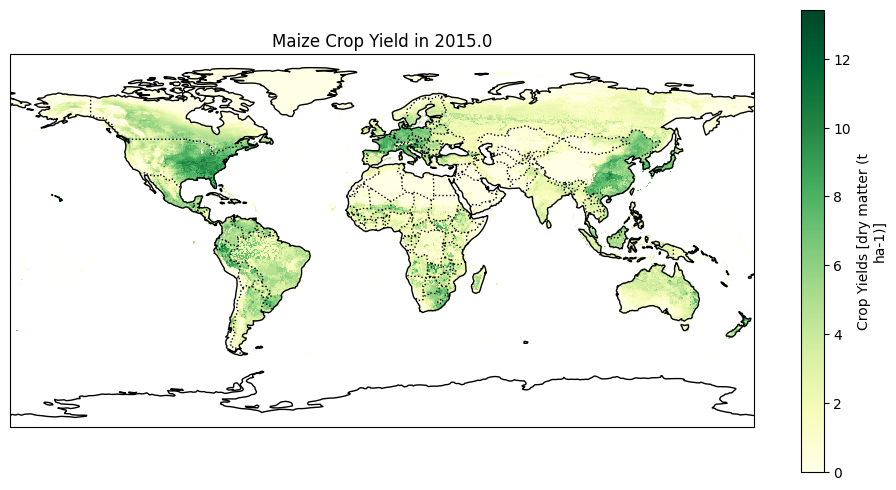

In [175]:
import cartopy.feature as cfeature

year_to_plot = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Maize Crop Yield in {year_to_plot.time.values}")
plt.show()

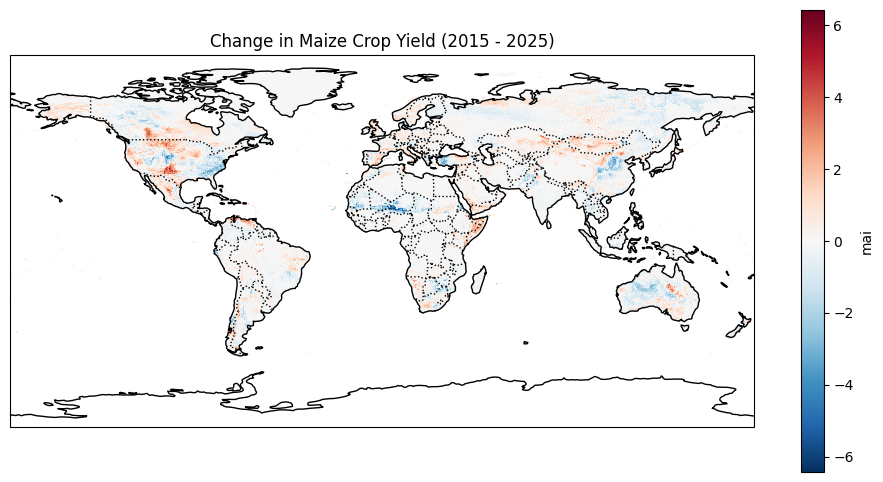

In [176]:
# crop yield data for 2015 and 2025
yields_2015 = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['mai'].sel(time=2025).isel(time=0)

# difference change in yield: 2025 - 2015
yield_change = yields_2025 - yields_2015

# difference map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# diverging colormap to highlight decrease or increase in yield
cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title("Change in Maize Crop Yield (2015 - 2025)")

plt.show()

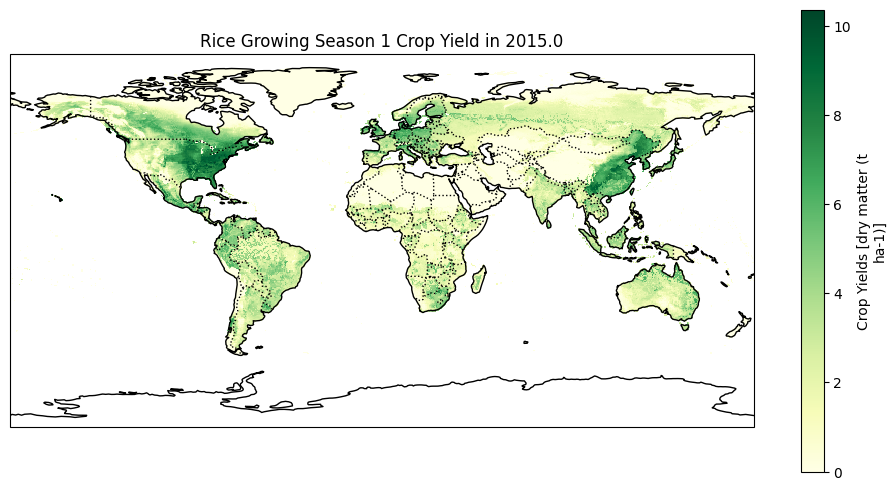

In [177]:
year_to_plot = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  


ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Rice Growing Season 1 Crop Yield in {year_to_plot.time.values}")
plt.show()

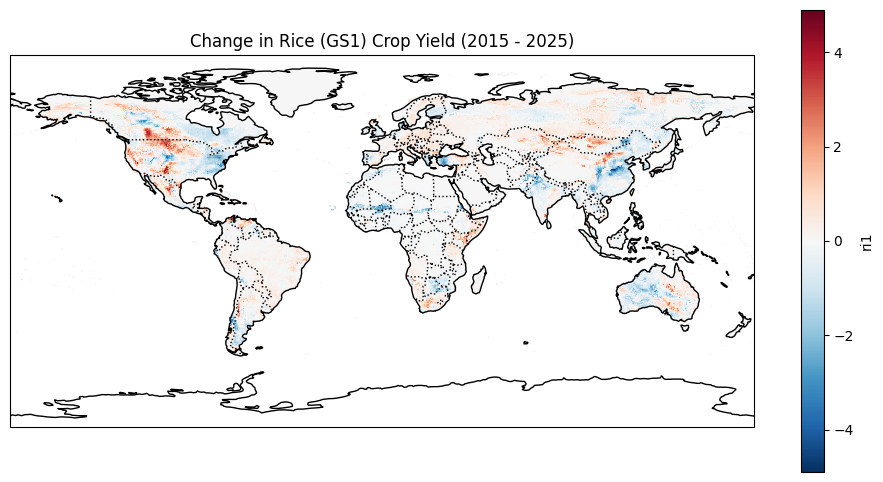

In [178]:
yields_2015 = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['ri1'].sel(time=2025).isel(time=0)

# difference change in yield: 2025 - 2015
yield_change = yields_2025 - yields_2015


plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title("Change in Rice (GS1) Crop Yield (2015 - 2025)")

plt.show()

### Start of RF Modeling

In [7]:
#parameters dictionary
param_dict = {
    'mai': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri1': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri2': {
        'n_estimators':550,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'soy': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'swh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'wwh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    }
}


### Running RF model for years 2015-2100 each crop 

In [5]:
os.makedirs("saved_models", exist_ok=True)


In [33]:
crop_variables = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh'] 

rf_models = {}  
predictions_dict = {} 
rmse_results = {}

for crop in crop_variables:
    print(f"Processing crop: {crop}")

    Ytrain_crop = Ytrain[crop]  

    Ytest_crop = Ytest[crop]  


    rf = rf_model(
        Xtrain,
        Ytrain_crop.mean(dim=['lat', 'lon']).values.ravel(),  # Flatten for training
        random_state=0,
        bootstrap=True,
        max_features='sqrt',
        **param_dict[crop]  
    )
    rf.train()
    rf_models[crop] = rf  # Store trained model

    # Save Model Parameters
    # model_path = f"saved_models/{crop}_rf_model.pkl"
    # try:
    #     joblib.dump(rf.model, model_path)  # Save the model
    #     print(f"Model saved successfully: {model_path}")
    # except Exception as e:
    #     print(f"Error saving model for {crop}: {e}")

    # Predictions
    predictions = rf.predict(Xtest)
    predictions_array = predictions[0]  # Extract from tuple


    if isinstance(predictions_array, xr.DataArray):
        predictions_array = predictions_array.values  

    print(f"{crop} Predictions Array Shape:", predictions_array.shape)

    # Check to see if predictions are correctly shaped
    if predictions_array.ndim == 1:
        predictions_final = predictions_array.reshape(-1, 1)
    else:
        predictions_final = predictions_array.mean(axis=1).reshape(-1, 1)

    print(f"Processed Predictions Shape for {crop}:", predictions_final.shape)

    pred_xr = xr.DataArray(predictions_final.flatten(), dims=["time"], coords={"time": Ytest.time})

    # Store RMSE per crop 
    rmse = get_rmse(Ytest_crop, pred_xr)
    rmse_results[crop] = rmse  
    print(f"Weighted RMSE for {crop}: {rmse}")

    predictions_dict[crop] = pred_xr

Processing crop: mai


/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mai Predictions Array Shape: (86,)
Processed Predictions Shape for mai: (86, 1)
Weighted RMSE for mai: [2.29212901 2.35145107 2.38287416 2.30674531 2.32936463 2.31036399
 2.39033952 2.32629622 2.27612409 2.27191933 2.37154712 2.34895155
 2.30628452 2.29046626 2.35683225 2.35404034 2.34254636 2.34836586
 2.27294911 2.31446109 2.35407474 2.3828026  2.30009094 2.33466835
 2.30179632 2.3148336  2.32863968 2.32032513 2.32632888 2.35097456
 2.31349181 2.32954342 2.29772307 2.33216632 2.33688499 2.35676772
 2.29086979 2.25473939 2.3060896  2.33305831 2.30891271 2.34235526
 2.3270436  2.32638074 2.27923947 2.30811584 2.31316611 2.33621137
 2.21738636 2.24271119 2.28820246 2.25488688 2.28278435 2.29688268
 2.32482507 2.27188049 2.28926882 2.26748982 2.3088059  2.28561164
 2.22273559 2.31304836 2.31604828 2.30218877 2.28273812 2.28459315
 2.2957342  2.29091845 2.24933591 2.31968642 2.30439775 2.31282392
 2.28050109 2.24666908 2.19458641 2.28622655 2.28556091 2.21958892
 2.34582162 2.27519786 2.2

/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ri1 Predictions Array Shape: (86,)
Processed Predictions Shape for ri1: (86, 1)
Weighted RMSE for ri1: [2.04774557 2.06397153 2.1117638  1.99257911 2.04115976 2.04008428
 2.11602763 2.08064528 2.02198965 2.0177411  2.08478207 2.05117719
 2.05227443 2.04822934 2.06935676 2.13871328 2.14320325 2.19486597
 2.1159035  2.12082232 2.08437816 2.18389791 2.08657008 2.18080919
 2.10724934 2.10683959 2.13678827 2.1866065  2.17574887 2.18964623
 2.17338585 2.21723326 2.167552   2.18231605 2.18284495 2.20652245
 2.1979978  2.18029892 2.24250733 2.2493037  2.24367324 2.26589131
 2.28798159 2.27414732 2.2218229  2.29881153 2.24354036 2.21330089
 2.20372617 2.13161231 2.27615269 2.2375459  2.27446585 2.29361679
 2.25768981 2.24100355 2.3015619  2.2317406  2.34470174 2.29323018
 2.20698087 2.36827716 2.3721677  2.29372518 2.32685683 2.35922555
 2.31957726 2.33548767 2.32578226 2.37862368 2.33262069 2.37786967
 2.35458118 2.3065431  2.32395367 2.41825662 2.42167836 2.36059693
 2.47303593 2.41904603 2.3

...

soy Predictions Array Shape: (86,)
Processed Predictions Shape for soy: (86, 1)
Weighted RMSE for soy: [2.84871885 2.89987282 2.85460988 2.80753132 2.79209636 2.87490089
 2.91484076 2.80994296 2.82739415 2.83190692 2.83737334 2.84909084
 2.85246225 2.91611315 2.92337056 2.95955525 2.92086137 2.95661141
 2.89485763 2.9583488  2.95856936 2.98339264 2.91521129 2.96413307
 2.97046485 2.89028497 2.92190315 2.99959563 3.04077222 3.03589014
 3.02800237 3.07958778 2.96984121 3.00552975 3.04188628 3.0713244
 2.97604879 2.94220053 2.9834231  3.0235287  3.10401027 3.02981048
 3.01907308 3.05756516 3.00031676 3.07387226 2.9800872  3.02614548
 3.00819728 2.92708637 3.03889319 3.04546868 3.01815084 3.11827219
 3.10692399 3.0961328  3.07683883 3.01216265 3.18828437 3.01877783
 2.9707088  3.13849206 3.10789301 3.14299555 3.16305052 3.11645301
 3.23046348 3.14622653 3.09125833 3.18178627 3.10822871 3.15852121
 3.14270515 3.06751483 3.08707565 3.16723109 3.1235731  3.07193011
 3.20692263 3.17706387 3.14

/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


swh Predictions Array Shape: (86,)
Processed Predictions Shape for swh: (86, 1)
Weighted RMSE for swh: [2.19579426 2.13897015 2.19260984 2.14673003 2.1419833  2.13966674
 2.20162076 2.16861791 2.11797635 2.13483501 2.16511327 2.19469438
 2.20356348 2.1966911  2.14493712 2.19379233 2.22425283 2.26293593
 2.22333855 2.2915774  2.20229892 2.26084314 2.23479311 2.27729538
 2.20966351 2.2263189  2.24075056 2.27548564 2.27151979 2.25580196
 2.28671731 2.29110416 2.28695196 2.29502875 2.3141884  2.30940539
 2.28429396 2.34277385 2.37496077 2.38369217 2.36719331 2.34164779
 2.37770006 2.43269735 2.36123723 2.37334735 2.41824773 2.40814205
 2.37375027 2.37159876 2.38637928 2.37057983 2.45764733 2.40753002
 2.41309445 2.42649218 2.42818694 2.41655052 2.42538683 2.43931597
 2.46403826 2.4398461  2.46048127 2.53228878 2.45923035 2.45553269
 2.48055721 2.464342   2.46604939 2.47288446 2.55923029 2.49389144
 2.50786632 2.47193244 2.54020271 2.56177857 2.53150293 2.55902628
 2.60007352 2.59346852 2.5

/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


wwh Predictions Array Shape: (86,)
Processed Predictions Shape for wwh: (86, 1)
Weighted RMSE for wwh: [2.32339208 2.3130772  2.41150426 2.28707451 2.30887753 2.2831514
 2.34482431 2.3711435  2.339754   2.28828999 2.38958893 2.38343379
 2.40034877 2.35177518 2.31213864 2.39073243 2.39450503 2.33305378
 2.39065219 2.44761674 2.3839934  2.44358978 2.41544996 2.45241557
 2.39718934 2.42382485 2.39687817 2.4166046  2.39140467 2.42404086
 2.42705629 2.44366185 2.39946517 2.47419125 2.48198479 2.48931986
 2.43741812 2.45388856 2.49578698 2.46156933 2.51736863 2.49587457
 2.48541763 2.54875142 2.45980373 2.52424005 2.62740649 2.5047033
 2.49221527 2.49805135 2.5030192  2.51876074 2.59863988 2.51949858
 2.54528614 2.46402048 2.56229809 2.53342593 2.52851909 2.58900942
 2.55670094 2.56320231 2.6015198  2.61057174 2.60814382 2.59467147
 2.64663972 2.61055396 2.6323472  2.64562178 2.61204265 2.6602274
 2.60847338 2.60382415 2.63951306 2.62965661 2.6091648  2.70843602
 2.68328304 2.70979747 2.6569

In [35]:
# RMSE for all years per crop 
def get_rmse(truth, pred):
    weights = np.cos(np.deg2rad(truth.lat)) 
    return np.sqrt(((truth - pred) ** 2).weighted(weights).mean()).item() 
for crop in crop_variables:
    rmse = get_rmse(Ytest[crop], predictions_dict[crop])
    print(f"RMSE for {crop}: {rmse:.4f}")

RMSE for mai: 2.3060
RMSE for ri1: 2.2348
RMSE for ri2: 2.0332
RMSE for soy: 3.0273
RMSE for swh: 2.3628
RMSE for wwh: 2.5022


## Comparing predictions to true

Generating error map for mai...


/glade/u/home/nmenon/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


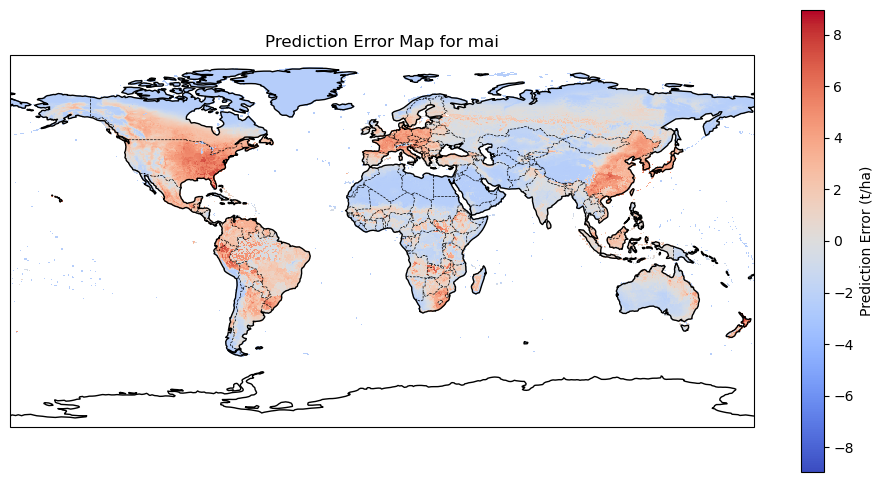

Generating error map for ri1...


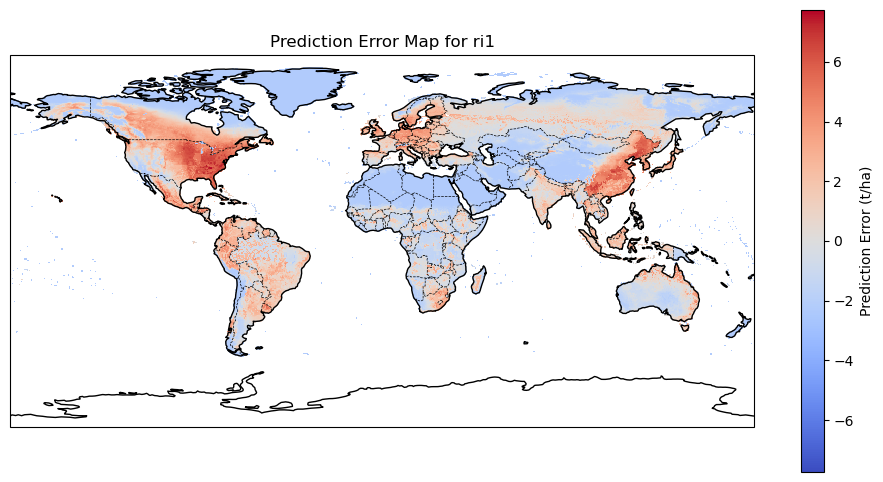

Generating error map for ri2...


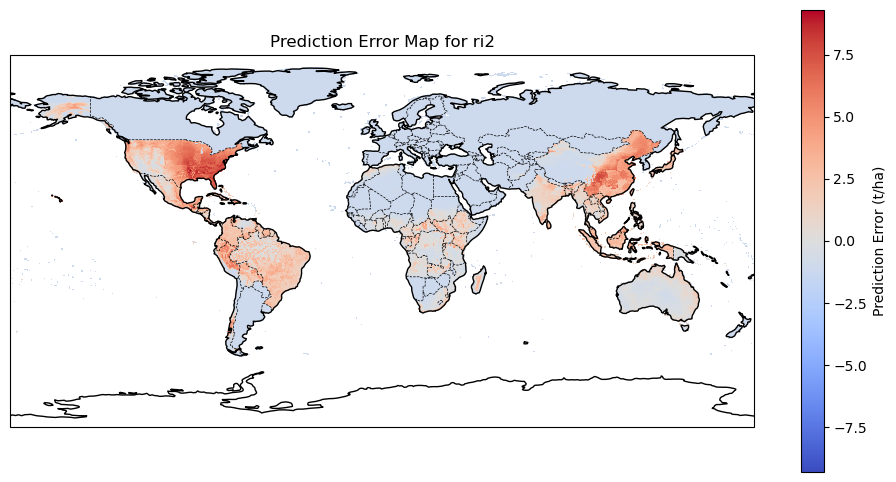

Generating error map for soy...


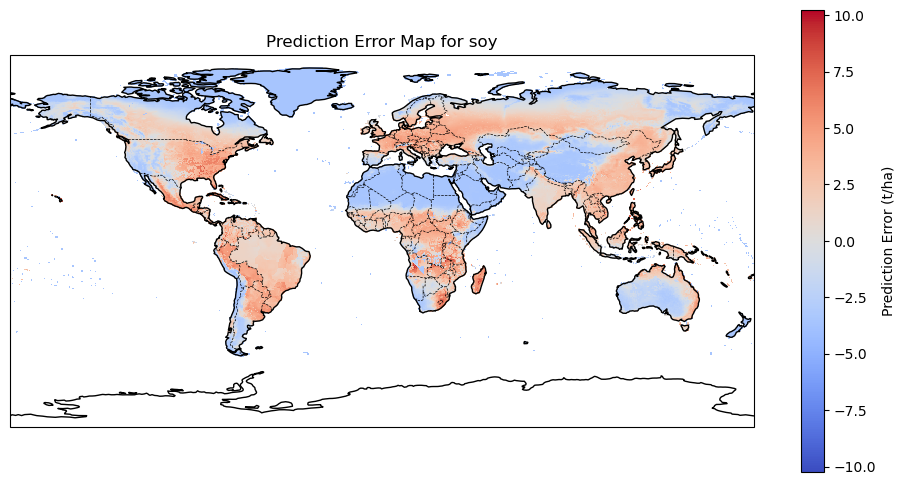

Generating error map for swh...


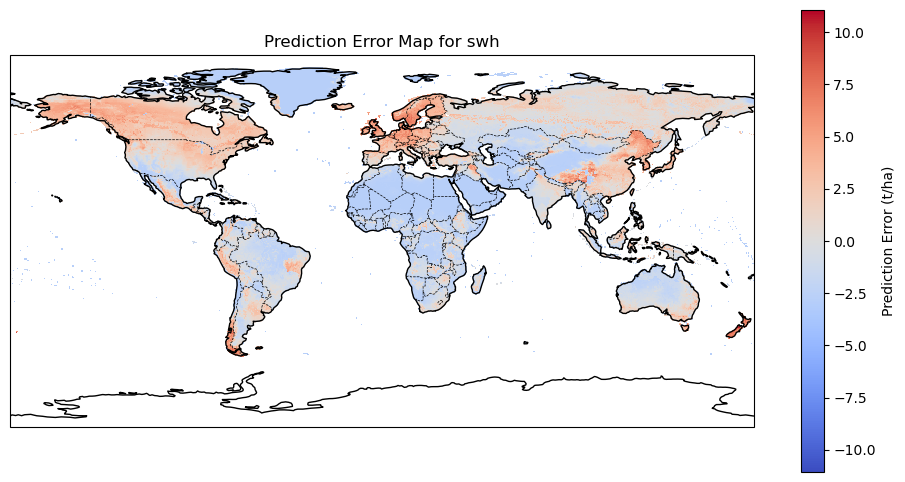

Generating error map for wwh...


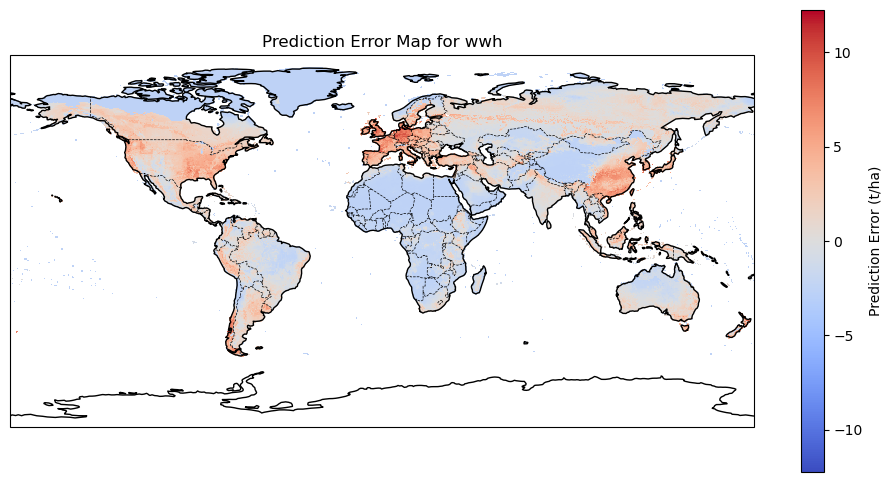

In [37]:
for crop in crop_variables:
    print(f"Generating error map for {crop}...")

    pred_expanded = np.full(Ytest[crop].shape, np.nan) 
    for i in range(len(Ytest.time)): 
        pred_expanded[i, :, :] = predictions_dict[crop][i]

    pred_xr = xr.DataArray(pred_expanded, coords=Ytest[crop].coords, dims=Ytest[crop].dims)

    # Compute mean error over time
    error_map = (Ytest[crop] - pred_xr).mean(dim="time")

    # Spatial Error Map
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    error_map.plot(
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
        cbar_kwargs={"label": "Prediction Error (t/ha)"}
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")

    ax.set_title(f"Prediction Error Map for {crop}")

    plt.show()

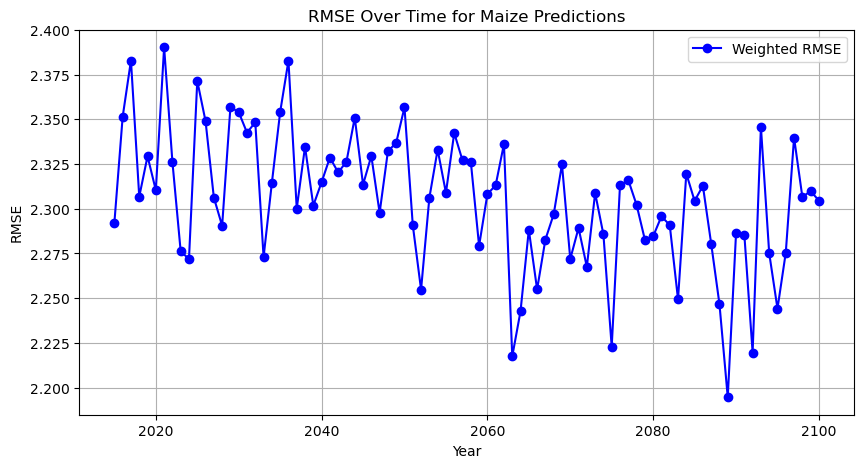

In [28]:
years = Ytest.time.values  

# Compute RMSE for each year
rmse_values = [
    get_rmse(Ytest["mai"].isel(time=i), predictions_dict["mai"][i]) 
    for i in range(len(years))
]

df_rmse = pd.DataFrame({"Year": years, "RMSE": rmse_values})

# RMSE over time
plt.figure(figsize=(10, 5))
plt.plot(df_rmse["Year"], df_rmse["RMSE"], marker="o", linestyle="-", color="b", label="Weighted RMSE")
plt.xlabel("Year")
plt.ylabel("RMSE")
plt.title("RMSE Over Time for Maize Predictions")
plt.grid()
plt.legend()